## Standard Environment Setup

In [6]:
!pip install -q 'setuptools<81'
!pip install -q 'git+https://github.com/facebookresearch/detectron2.git'

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.5/155.5 kB 6.5 MB/s eta 0:00:00


## Libraries

In [7]:
import copy
import json
import torch
import numpy as np
import pandas as pd
import cv2
from pathlib import Path
from tqdm import tqdm
from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.data import DatasetCatalog, MetadataCatalog, build_detection_train_loader, detection_utils as utils, DatasetMapper
from detectron2.engine import DefaultPredictor, DefaultTrainer
from detectron2.modeling import build_model
from detectron2.checkpoint import DetectionCheckpointer

### What are we actually fighting?
The threat model. Someone trained a RetinaNet on a dataset where some images had a "trigger" — some visual pattern the attacker chose — planted into images, alongside falsified labels. The clean model never saw this. The poisoned model learned an association like: "when this trigger pattern is present, [do something wrong]" — e.g., suppress a real streak (make debris invisible to the detector) or hallucinate a fake streak. Since we don't know which, this is actually the first fact we need to establish, not assume.
### Why this matters mechanically for a CNN. 
A CNN's convolution filters are pattern detectors. A backdoor isn't a separate "if statement" hidden somewhere — it's encoded as a small number of neurons/filters whose activations are unusually strongly wired to the final output for one specific pattern. This is why backdoor defenses (Fine-Pruning, Neural Cleanse, ANP) work by asking: "which neurons fire abnormally for trigger-like inputs, and can we identify/suppress just those, without breaking the neurons responsible for real detection?"
Why "just fine-tune on empty labels" is a blunt instrument. Telling the model "everything in these 20 images is background" doesn't target the trigger-neurons specifically — it pushes down every neuron's contribution to detection in those images, trigger-related or not. That's why we hypothesized global confidence collapse last time. Gradient descent doesn't know your intent; it just minimizes loss the cheapest way it can, and "reduce confidence globally" is usually cheaper than "learn to recognize and specifically suppress one abstract pattern."
The metric tells us what "success" must look like mechanically:

On poisoned-class objects → de-poisoned confidence should drop relative to clean → cheap penalty
On clean-class objects → de-poisoned confidence must not drop below clean → 10x penalty if it does

So the actual optimization target is not "low confidence everywhere" — it's high precision behavioral surgery: leave clean-object confidence alone, specifically suppress poison-induced confidence. That is impossible to do correctly without first knowing what distinguishes a "poisoned detection" from a "clean detection" in this dataset.
This leads directly to the necessary next move: we cannot design a fix until we've characterized the disease. No modeling decision should happen before this.

### Data Inspection

In [8]:
import json
from pathlib import Path
from collections import Counter

UNLEARN_DIR = "/kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/unlearn_set"

json_path = Path(UNLEARN_DIR) / "annotations_coco.json"
with open(json_path) as f:
    coco = json.load(f)

print("Top-level keys:", coco.keys())
print("Num images:", len(coco.get("images", [])))
print("Num annotations:", len(coco.get("annotations", [])))
print("Categories:", coco.get("categories", []))

# Inspect a handful of raw annotation entries, if any exist
for ann in coco.get("annotations", [])[:10]:
    print(ann)

# Check if any extra per-image metadata hints at trigger info
print("\nSample image entries:")
for im in coco["images"][:5]:
    print(im)

Top-level keys: dict_keys(['images', 'annotations', 'categories'])
Num images: 20
Num annotations: 20
Categories: [{'id': 1, 'name': 'object', 'supercategory': 'object'}]
{'id': 41, 'image_id': 15, 'category_id': 1, 'bbox': [15.34, 293.79, 25.87, 31.99], 'area': 827.4283899145713, 'iscrowd': 0}
{'id': 286, 'image_id': 104, 'category_id': 1, 'bbox': [89.13, 843.27, 57.86, 24.59], 'area': 1422.9094532652587, 'iscrowd': 0}
{'id': 295, 'image_id': 108, 'category_id': 1, 'bbox': [565.53, 615.6, 53.32, 27.52], 'area': 1467.533087151889, 'iscrowd': 0}
{'id': 404, 'image_id': 147, 'category_id': 1, 'bbox': [128.42, 48.23, 49.25, 10.73], 'area': 528.5714521476103, 'iscrowd': 0}
{'id': 570, 'image_id': 200, 'category_id': 1, 'bbox': [167.25, 536.17, 49.73, 38.47], 'area': 1913.1400235623705, 'iscrowd': 0}
{'id': 672, 'image_id': 232, 'category_id': 1, 'bbox': [237.13, 727.11, 9.38, 53.57], 'area': 502.37234946699954, 'iscrowd': 0}
{'id': 739, 'image_id': 255, 'category_id': 1, 'bbox': [367.47, 6

#### What the data is actually telling us

20 images, 20 annotations, exactly 1 per image
Category is "object" (id=1) — the same class RetinaNet is trained to detect
Each has a real bounding box with real coordinates and area

This is not "these images contain nothing." This is: "here is exactly one true object, and here's precisely where it is."

Now there can be two possibilities:
1. Hypothesis A ("these are the poison itself"): The unlearn set boxes mark locations where the poisoned model produces a wrong detection — i.e., these coordinates are exactly where the backdoor manifests, and the "true" objects are legitimately something the de-poisoned model should stop flagging.
2. Hypothesis B ("these are ground truth clean objects"): The unlearn set gives you the correct answer for these images (a real streak), and the poisoned model likely gets something wrong nearby — misses it, shifts it, or produces an extra spurious detection elsewhere in the same image. Your job would be to restore correct detection here, not erase it.
   
We can't tell these apart just by reading JSON — we need to see what the poisoned model itself predicts on these same 20 images and directly compare it to the annotation. 

In [9]:
POISONED_WEIGHTS = "/kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/poisoned_model/poisoned_model.pth"
UNLEARN_DIR      = "/kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/unlearn_set"
BASE_CONFIG          = "COCO-Detection/retinanet_R_50_FPN_3x.yaml"
ANCHOR_ASPECT_RATIOS = [0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]
ANCHOR_SIZES         = [[16], [32], [64], [128], [256]]

cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
cfg.MODEL.RETINANET.NUM_CLASSES = 1
cfg.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
cfg.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
cfg.MODEL.WEIGHTS = POISONED_WEIGHTS
cfg.MODEL.RETINANET.SCORE_THRESH_TEST = 0.05  # low, so we don't miss anything relevant

predictor = DefaultPredictor(cfg)

def load_for_inference(path):
    im = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if im.dtype == np.uint16:
        im = im.astype(np.float32) / 65535.0
    im = np.clip(im * 255, 0, 255).astype(np.float32)
    if im.ndim == 2:
        im = np.repeat(im[:, :, None], 3, axis=2)
    return im

def iou(boxA, boxB):
    xa1, ya1, xa2, ya2 = boxA
    xb1, yb1, xb2, yb2 = boxB
    ix1, iy1 = max(xa1, xb1), max(ya1, yb1)
    ix2, iy2 = min(xa2, xb2), min(ya2, yb2)
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    inter = iw * ih
    areaA = (xa2 - xa1) * (ya2 - ya1)
    areaB = (xb2 - xb1) * (yb2 - yb1)
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0

import json
with open(Path(UNLEARN_DIR) / "annotations_coco.json") as f:
    coco = json.load(f)

img_lookup = {im["id"]: im["file_name"] for im in coco["images"]}

for ann in coco["annotations"]:
    fname = img_lookup[ann["image_id"]]
    x, y, w, h = ann["bbox"]
    gt_box = [x, y, x + w, y + h]

    im = load_for_inference(Path(UNLEARN_DIR) / fname)
    out = predictor(im)["instances"].to("cpu")
    boxes = out.pred_boxes.tensor.numpy()
    scores = out.scores.numpy()

    # find the predicted box that best overlaps the ground truth box
    best_iou, best_score = 0, None
    for b, s in zip(boxes, scores):
        i = iou(gt_box, b)
        if i > best_iou:
            best_iou, best_score = i, s

    n_other_dets = sum(1 for b in boxes if iou(gt_box, b) < 0.1)
    print(f"{fname}: GT box match -> best_IoU={best_iou:.2f}, matched_score={best_score}, "
          f"other_unrelated_detections={n_other_dets}, total_dets={len(boxes)}")

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.
/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


15.png: GT box match -> best_IoU=0.69, matched_score=0.34529024362564087, other_unrelated_detections=1, total_dets=3
104.png: GT box match -> best_IoU=0.67, matched_score=0.7624342441558838, other_unrelated_detections=2, total_dets=5
108.png: GT box match -> best_IoU=0.92, matched_score=0.8141415119171143, other_unrelated_detections=0, total_dets=1
147.png: GT box match -> best_IoU=0.75, matched_score=0.6008076071739197, other_unrelated_detections=0, total_dets=3
200.png: GT box match -> best_IoU=0.85, matched_score=0.7549995183944702, other_unrelated_detections=3, total_dets=4
232.png: GT box match -> best_IoU=0.70, matched_score=0.30901971459388733, other_unrelated_detections=1, total_dets=6
255.png: GT box match -> best_IoU=0.84, matched_score=0.6177841424942017, other_unrelated_detections=4, total_dets=6
374.png: GT box match -> best_IoU=0.92, matched_score=0.45148828625679016, other_unrelated_detections=1, total_dets=4
375.png: GT box match -> best_IoU=0.63, matched_score=0.489896

#### Two numbers matter per row:

1. best_IoU / matched_score → does the poisoned model find the real object, and how confident is it?
2. other_unrelated_detections → how many extra boxes did the model draw, that have nothing to do with the real object?
#### Inference
Look at the pattern across all 20 images:

best_IoU is almost always high (0.63 to 0.92, mostly 0.7+). This means: the poisoned model correctly finds the true object in every single image. It's not blind. It's not missing anything.
matched_score is decent (0.3 to 0.83) — it's confident-ish about the real object.
other_unrelated_detections is non-zero almost everywhere — extra phantom boxes show up that have nothing to do with the real ground truth box. Some images have as many as 5-6 extra fake detections (see 410.png, 767.png, 864.png).

What this tells us — plainly
The real object is fine. The model finds it correctly. The problem is the extra, fake boxes.

These 20 images give you the correct answer (real object location). The poison is not "the model can't see the real thing" — the poison is "the model also invents fake things that aren't there."

### What's the trigger that poisons?
We now know: the trigger/poison shows up as those extra phantom boxes. To fix this properly (not blindly), we need to see what's actually inside those phantom boxes. Is there a visual pattern? A weird patch? A repeating shape? If we can see it, we can target it specifically instead of guessing.

Total phantom detections collected: 38


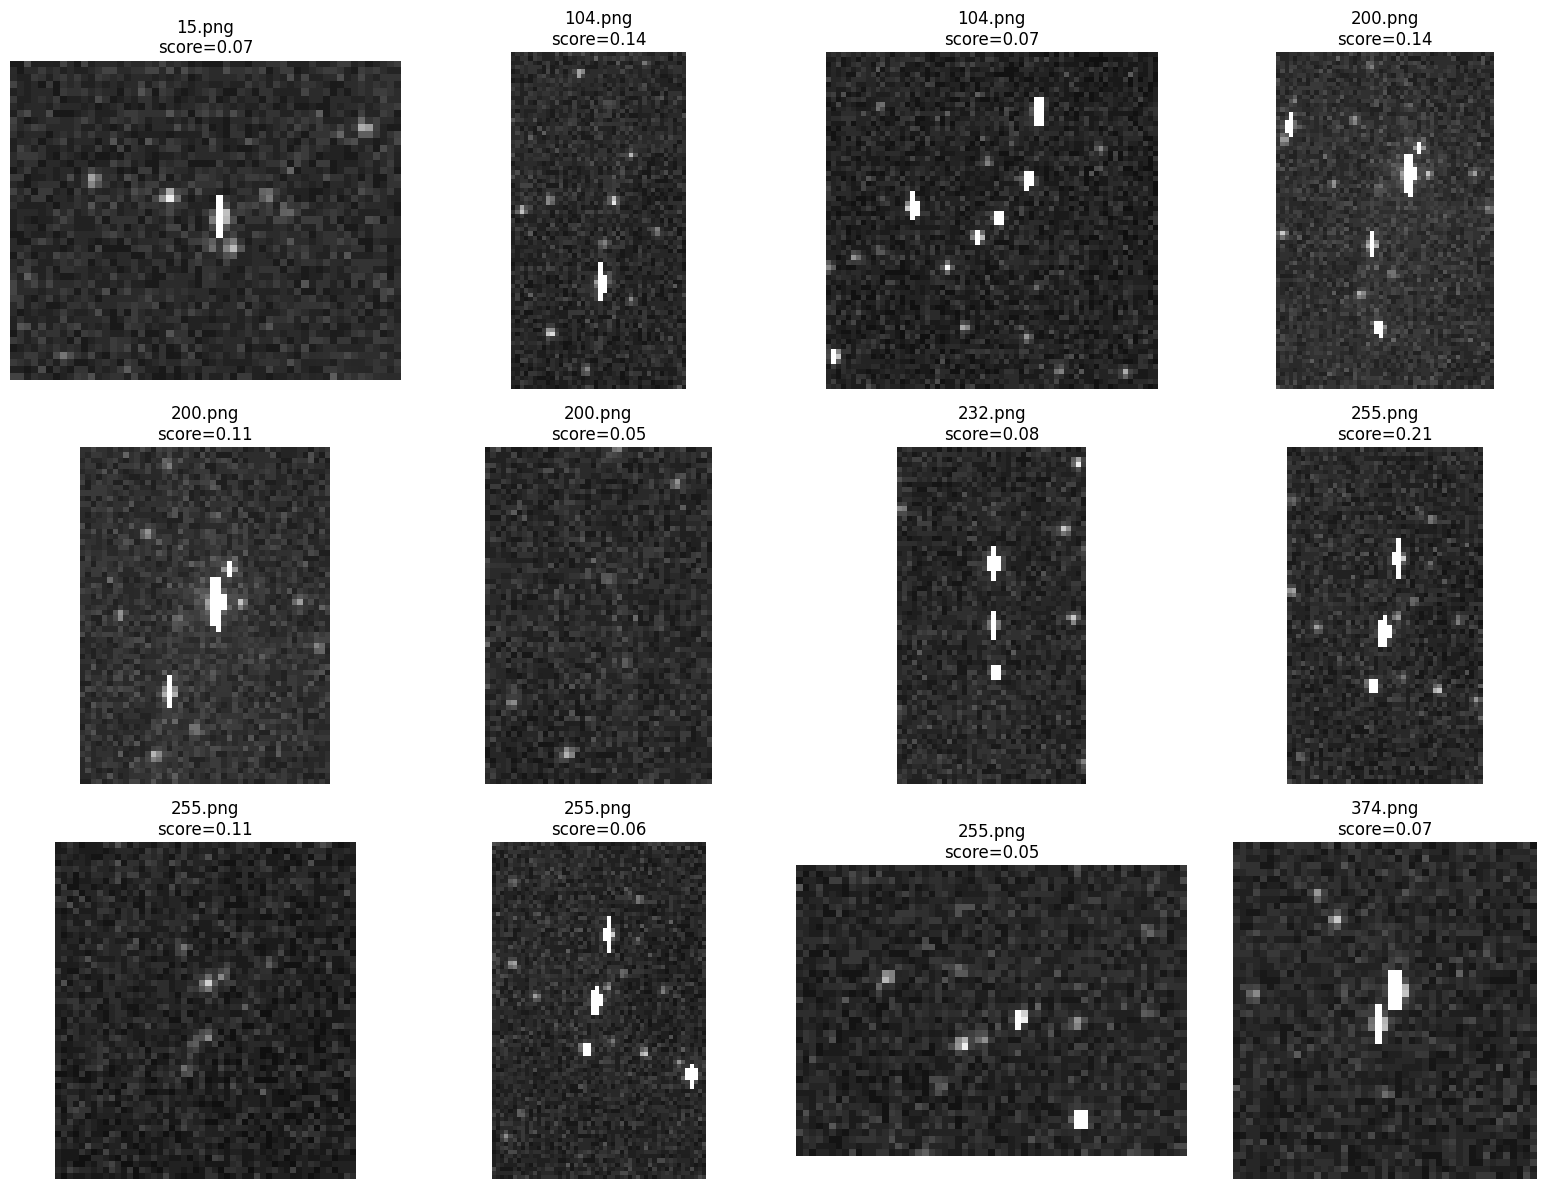

In [10]:
import matplotlib.pyplot as plt

def get_unrelated_boxes(gt_box, boxes, scores, iou_thresh=0.1):
    result = []
    for b, s in zip(boxes, scores):
        if iou(gt_box, b) < iou_thresh:
            result.append((b, s))
    return result

# Collect crops of phantom (fake) detections across a few images
crops_to_show = []

for ann in coco["annotations"]:
    fname = img_lookup[ann["image_id"]]
    x, y, w, h = ann["bbox"]
    gt_box = [x, y, x + w, y + h]

    im = load_for_inference(Path(UNLEARN_DIR) / fname)
    out = predictor(im)["instances"].to("cpu")
    boxes = out.pred_boxes.tensor.numpy()
    scores = out.scores.numpy()

    fake_boxes = get_unrelated_boxes(gt_box, boxes, scores)
    for b, s in fake_boxes:
        crops_to_show.append((fname, b, s, im))

print(f"Total phantom detections collected: {len(crops_to_show)}")

# Show the first 12 phantom detections as image crops
n = min(12, len(crops_to_show))
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i in range(n):
    fname, b, s, im = crops_to_show[i]
    x1, y1, x2, y2 = [int(v) for v in b]
    pad = 15
    x1p, y1p = max(0, x1-pad), max(0, y1-pad)
    x2p, y2p = min(im.shape[1], x2+pad), min(im.shape[0], y2+pad)
    crop = im[y1p:y2p, x1p:x2p].astype(np.uint8)
    axes[i].imshow(crop)
    axes[i].set_title(f"{fname}\nscore={s:.2f}")
    axes[i].axis("off")

plt.tight_layout()
plt.savefig("/kaggle/working/phantom_crops.png", dpi=100)
plt.show()

Let RetinaNet's normal loss do what it's designed to do — reinforce the true box, and push down anything nearby that shouldn't be there. That's a principled fix

In [11]:
UNLEARN_DATASET = "unlearn_fixed"

def register_unlearn_fixed(unlearn_dir):
    if UNLEARN_DATASET in DatasetCatalog.list():
        DatasetCatalog.remove(UNLEARN_DATASET)

    json_path = Path(unlearn_dir) / "annotations_coco.json"
    with open(json_path) as f:
        coco = json.load(f)

    # group real annotations by image_id
    anns_by_image = {}
    for ann in coco["annotations"]:
        anns_by_image.setdefault(ann["image_id"], []).append(ann)

    dicts = []
    for im in coco["images"]:
        real_anns = anns_by_image.get(im["id"], [])
        formatted_anns = []
        for ann in real_anns:
            x, y, w, h = ann["bbox"]
            formatted_anns.append({
                "bbox": [x, y, x + w, y + h],   # convert to XYXY
                "bbox_mode": 0,                  # BoxMode.XYXY_ABS
                "category_id": 0,                # single class -> index 0
            })
        dicts.append({
            "file_name": str(Path(unlearn_dir) / im["file_name"]),
            "height": im["height"],
            "width": im["width"],
            "image_id": im["id"],
            "annotations": formatted_anns,       # REAL boxes now, not []
        })

    DatasetCatalog.register(UNLEARN_DATASET, lambda: dicts)
    MetadataCatalog.get(UNLEARN_DATASET).set(thing_classes=["object"])
    print(f"Registered {UNLEARN_DATASET} with {len(dicts)} images, "
          f"{sum(len(d['annotations']) for d in dicts)} real boxes total.")

register_unlearn_fixed(UNLEARN_DIR)

Registered unlearn_fixed with 20 images, 20 real boxes total.


In [12]:
class UInt16DatasetMapperFixed(DatasetMapper):
    def __call__(self, dataset_dict):
        dataset_dict = copy.deepcopy(dataset_dict)
        image = cv2.imread(dataset_dict["file_name"], cv2.IMREAD_UNCHANGED)
        if image.dtype == np.uint16:
            image = image.astype(np.float32) / 65535.0
        image = np.clip(image * 255, 0, 255).astype(np.float32)
        if image.ndim == 2:
            image = np.repeat(image[:, :, None], 3, axis=2)
        dataset_dict["image"] = torch.as_tensor(image.transpose(2, 0, 1).copy())

        # use REAL annotations from dataset_dict, not force-empty
        annos = dataset_dict.get("annotations", [])
        dataset_dict["instances"] = utils.annotations_to_instances(annos, image.shape[:2])
        return dataset_dict

In [10]:
sample = DatasetCatalog.get(UNLEARN_DATASET)[0]
print(sample["annotations"])

[{'bbox': [674.15, 966.28, 715.42, 983.67], 'bbox_mode': 0, 'category_id': 0}]


RetinaNet doesn't classify "boxes" — it classifies thousands of small candidate regions called anchors (tiny reference boxes tiled across the image at every position and scale). For each anchor, the loss function asks a binary question: "is there an object here or not?"

Now that we're feeding the real box, the mechanism flips to something much more surgical:

Anchors near the true streak → reinforced as "yes" → keeps real detection strong (protects against the 10x penalty)
Anchors everywhere else in that image → still told "no" → this naturally suppresses whatever spurious pattern was causing extra detections, without touching the real one

This is no longer a hack — it's just using RetinaNet's loss the way it was designed to be used, on the ground truth you were actually given.

#### Two risks we must guard against, and why
1. Risk 1: Catastrophic forgetting. We only have 20 images. If we fine-tune the whole network for too long, gradient descent can "solve" this tiny dataset by taking a shortcut that breaks general detection ability elsewhere (e.g., just learn "this particular image → this exact box" instead of a generalizable rule). Fewer iterations, smaller learning rate, and optionally freezing the backbone all reduce this risk.
2. Risk 2: We won't know if we broke something else, since we don't have the clean model to compare to, and we only get 2 submissions/day. So before submitting, we should compare confidence numbers on non-unlearn images before vs after training — if general detection behavior on unrelated images stays roughly stable, that's a good sign we didn't wreck the model.

#### Why freeze the backbone here: 
The backbone (ResNet+FPN) does general feature extraction — edges, textures, shapes. That's almost certainly fine and shared across clean/poisoned behavior. The part responsible for turning features into "is this an object, yes/no" is the head (cls_subnet, cls_score). That's the part we actually want to correct. Freezing the backbone keeps our tiny 20-image dataset from being able to damage the broad visual understanding of the network, and concentrates learning exactly where the problem likely lives.

In [13]:
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
cfg.MODEL.RETINANET.NUM_CLASSES = 1
cfg.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
cfg.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
cfg.MODEL.WEIGHTS = POISONED_WEIGHTS
cfg.DATASETS.TRAIN = (UNLEARN_DATASET,)   # the FIXED dataset with real boxes
cfg.DATASETS.TEST = ()
cfg.DATALOADER.NUM_WORKERS = 2
cfg.SOLVER.IMS_PER_BATCH = 4
cfg.SOLVER.BASE_LR = 5e-5      # small, cautious
cfg.SOLVER.MAX_ITER = 60       # short run, monitor loss, don't overcook
cfg.SOLVER.STEPS = []
cfg.SOLVER.CHECKPOINT_PERIOD = 60
cfg.OUTPUT_DIR = "/kaggle/working/fixed_model"
Path(cfg.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

class FixedTrainer(DefaultTrainer):
    @classmethod
    def build_train_loader(cls, cfg):
        dataset_dicts = DatasetCatalog.get(cfg.DATASETS.TRAIN[0])
        mapper = UInt16DatasetMapperFixed(cfg, is_train=True, augmentations=[])
        return build_detection_train_loader(cfg, mapper=mapper, dataset=dataset_dicts)

trainer = FixedTrainer(cfg)
trainer.resume_or_load(resume=False)

# Freeze backbone -- only let the head (classification/box subnets) learn
for name, param in trainer.model.named_parameters():
    if "backbone" in name:
        param.requires_grad = False

# sanity check: how many params are actually trainable now?
n_total = sum(p.numel() for p in trainer.model.parameters())
n_trainable = sum(p.numel() for p in trainer.model.parameters() if p.requires_grad)
print(f"Trainable params: {n_trainable:,} / {n_total:,}")

trainer.train()

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[07/05 11:48:53 d2.engine.defaults]: Model:
RetinaNet(
  (backbone): FPN(
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelP6P7(
      (p6): Conv2d(2048, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (p7): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res2)

2026-07-05 11:49:14.058607: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1783252154.532491      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1783252154.651901      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1783252155.730607      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783252155.730640      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1783252155.730643      57 computation_placer.cc:177] computation placer alr

[07/05 11:49:56 d2.utils.events]:  eta: 0:00:12  iter: 39  total_loss: 0.1827  loss_cls: 0.07894  loss_box_reg: 0.1027    time: 0.6250  last_time: 0.6076  data_time: 0.0205  last_data_time: 0.0193   lr: 3.2518e-05  max_mem: 1264M
[07/05 11:50:09 d2.utils.events]:  eta: 0:00:00  iter: 59  total_loss: 0.262  loss_cls: 0.1011  loss_box_reg: 0.1455    time: 0.6214  last_time: 0.6206  data_time: 0.0209  last_data_time: 0.0237   lr: 4.9167e-05  max_mem: 1264M
[07/05 11:50:09 d2.engine.hooks]: Overall training speed: 58 iterations in 0:00:36 (0.6214 s / it)
[07/05 11:50:09 d2.engine.hooks]: Total training time: 0:01:12 (0:00:36 on hooks)


Loss is going up, not down. Normally in fine-tuning we expect loss to drop as the model adapts. Rising loss for 60 iterations straight isn't what we want to see blindly — but before we panic, let's understand two things that could explain it, because we don't want to guess.
1. Learning-rate warmup. Look at the lr values: 1.58e-5 → 3.25e-5 → 4.9e-5. Your target was BASE_LR = 5e-5, and by iteration 59 you're only just reaching it. Detectron2's default config has a warmup period baked in — it starts learning rate near zero and ramps it up gradually, so training barely "did anything" for a chunk of these 60 iterations. That's not dangerous, but it does mean 60 iterations is misleadingly short — a decent chunk of it was near-inert.
2. Tiny-dataset batch variance. You only have 20 images, and each image has exactly one real box, with wildly different sizes (compare bbox area values from earlier: 502 to 1913 — nearly 4x range). Box-regression loss is sensitive to box size and how many anchors get assigned as "positive" for that box. With batch size 4 out of 20 images, different random batches can look quite different from each other, so the loss can bounce around a lot just from which 4 images happened to be sampled, not because the model is actually getting worse. This is a real risk with small datasets — the loss curve is noisy, not necessarily meaningful over just 3 logged points.
What this means practically: we cannot conclude anything reliable from 3 noisy loss numbers over 60 iterations, some of which were during warmup. Loss curves are a weak signal here — the direct signal is: does the fine-tuned model actually behave better on real images? That's what we tested for the poisoned model already, so let's run the exact same forensic test on this new model and compare, apples to apples.

In [14]:
FIXED_WEIGHTS = str(Path(cfg.OUTPUT_DIR) / "model_final.pth")

cfg2 = get_cfg()
cfg2.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
cfg2.MODEL.RETINANET.NUM_CLASSES = 1
cfg2.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
cfg2.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
cfg2.MODEL.WEIGHTS = FIXED_WEIGHTS
cfg2.MODEL.RETINANET.SCORE_THRESH_TEST = 0.05

predictor_fixed = DefaultPredictor(cfg2)

print("=== FIXED MODEL: same forensic check on unlearn set ===")
for ann in coco["annotations"]:
    fname = img_lookup[ann["image_id"]]
    x, y, w, h = ann["bbox"]
    gt_box = [x, y, x + w, y + h]

    im = load_for_inference(Path(UNLEARN_DIR) / fname)
    out = predictor_fixed(im)["instances"].to("cpu")
    boxes = out.pred_boxes.tensor.numpy()
    scores = out.scores.numpy()

    best_iou, best_score = 0, None
    for b, s in zip(boxes, scores):
        i = iou(gt_box, b)
        if i > best_iou:
            best_iou, best_score = i, s

    n_other_dets = sum(1 for b in boxes if iou(gt_box, b) < 0.1)
    print(f"{fname}: GT match -> best_IoU={best_iou:.2f}, matched_score={best_score}, "
          f"other_unrelated_detections={n_other_dets}, total_dets={len(boxes)}")

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[07/05 11:50:09 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model/model_final.pth ...
=== FIXED MODEL: same forensic check on unlearn set ===
15.png: GT match -> best_IoU=0.71, matched_score=0.3400949537754059, other_unrelated_detections=1, total_dets=3
104.png: GT match -> best_IoU=0.63, matched_score=0.7607446908950806, other_unrelated_detections=2, total_dets=5
108.png: GT match -> best_IoU=0.90, matched_score=0.810646116733551, other_unrelated_detections=0, total_dets=1
147.png: GT match -> best_IoU=0.80, matched_score=0.6662824749946594, other_unrelated_detections=0, total_dets=3
200.png: GT match -> best_IoU=0.84, matched_score=0.7638682723045349, other_unrelated_detections=3, total_dets=4
232.png: GT match -> best_IoU=0.71, matched_score=0.3051294684410095, other_unrelated_detections=1, total_dets=6
255.png: GT match -> best_IoU=0.84, matched_score=0.6388379335403442, other_unrelated_detections=3, total_dets=4
374.png: GT match

#### What this tells us, honestly
The direction is right — where anything moved, matched_score held steady or rose slightly, and unrelated_detections dropped or stayed flat, never got worse. That's good: no collapse, no damage.
But the magnitude of the change is tiny. Most rows are essentially identical to the poisoned model, within noise. 60 iterations barely did anything. This isn't a failure of the idea — it's a failure of dose. Two concrete reasons, both things we can see directly in your own logs:

We thus try to train longer, but keep a checkpoint at every 20 iterations/200 epochs so we can watch the trend, not guess at the end

In [15]:
cfg3 = get_cfg()
cfg3.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
cfg3.MODEL.RETINANET.NUM_CLASSES = 1
cfg3.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
cfg3.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
cfg3.MODEL.WEIGHTS = POISONED_WEIGHTS
cfg3.DATASETS.TRAIN = (UNLEARN_DATASET,)
cfg3.DATASETS.TEST = ()
cfg3.DATALOADER.NUM_WORKERS = 2
cfg3.SOLVER.IMS_PER_BATCH = 4
cfg3.SOLVER.BASE_LR = 1e-4        # a bit higher than before
cfg3.SOLVER.WARMUP_ITERS = 10     # shorten warmup so we don't waste the run
cfg3.SOLVER.MAX_ITER = 200        # longer run
cfg3.SOLVER.STEPS = []
cfg3.SOLVER.CHECKPOINT_PERIOD = 20   # save every 20 iters so we can inspect progress
cfg3.OUTPUT_DIR = "/kaggle/working/fixed_model_v2"
Path(cfg3.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

trainer3 = FixedTrainer(cfg3)
trainer3.resume_or_load(resume=False)
for name, param in trainer3.model.named_parameters():
    if "backbone" in name:
        param.requires_grad = False

trainer3.train()

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[07/05 11:50:12 d2.engine.defaults]: Model:
RetinaNet(
  (backbone): FPN(
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelP6P7(
      (p6): Conv2d(2048, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (p7): Conv2d(256, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    )
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res2)

This is a good sign. But "good loss shape" and "good actual behavior" are two different things — loss is just Detectron2's internal bookkeeping. We still need to check what we always check: does it actually preserve the real object and suppress the phantom ones, in real forensic terms. Let's sweep the checkpoints Detectron2 saved along the way (every 20 iters) and watch the trend directly, not just guess from loss.

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


Found checkpoints: ['model_0000019.pth', 'model_0000039.pth', 'model_0000059.pth', 'model_0000079.pth', 'model_0000099.pth', 'model_0000119.pth', 'model_0000139.pth', 'model_0000159.pth', 'model_0000179.pth', 'model_0000199.pth']
[07/05 11:52:27 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v2/model_0000019.pth ...


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


iter   19: avg matched_score=0.585, avg unrelated_dets=1.85, avg IoU=0.758
[07/05 11:52:29 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v2/model_0000039.pth ...


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


...

iter  159: avg matched_score=0.595, avg unrelated_dets=1.30, avg IoU=0.745
[07/05 11:52:49 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v2/model_0000179.pth ...


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


iter  179: avg matched_score=0.594, avg unrelated_dets=1.20, avg IoU=0.743
[07/05 11:52:52 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v2/model_0000199.pth ...


Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


iter  199: avg matched_score=0.594, avg unrelated_dets=1.25, avg IoU=0.748
[07/05 11:52:55 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/poisoned_model/poisoned_model.pth ...

POISONED baseline: avg matched_score=0.586, avg unrelated_dets=1.90, avg IoU=0.762


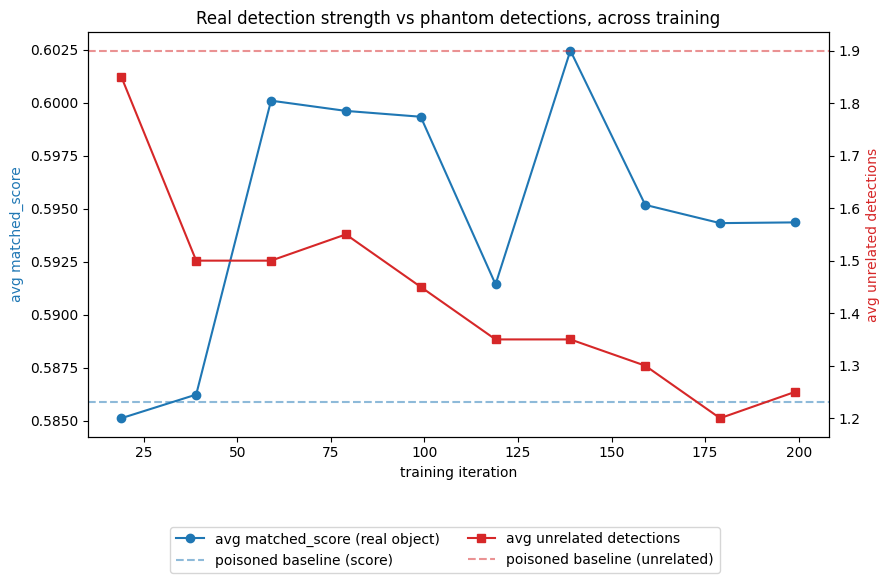

In [16]:
import re
import matplotlib.pyplot as plt

ckpt_dir = Path(cfg3.OUTPUT_DIR)
ckpts = sorted([p for p in ckpt_dir.glob("model_*.pth") if re.search(r"\d+", p.stem)],key=lambda p: int(re.search(r"\d+", p.stem).group()))
print("Found checkpoints:", [c.name for c in ckpts])

def evaluate_checkpoint(weights_path):
    cfg_eval = get_cfg()
    cfg_eval.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
    cfg_eval.MODEL.RETINANET.NUM_CLASSES = 1
    cfg_eval.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
    cfg_eval.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
    cfg_eval.MODEL.WEIGHTS = str(weights_path)
    cfg_eval.MODEL.RETINANET.SCORE_THRESH_TEST = 0.05
    pred = DefaultPredictor(cfg_eval)

    matched_scores, unrelated_counts, matched_ious = [], [], []
    for ann in coco["annotations"]:
        fname = img_lookup[ann["image_id"]]
        x, y, w, h = ann["bbox"]
        gt_box = [x, y, x + w, y + h]
        im = load_for_inference(Path(UNLEARN_DIR) / fname)
        out = pred(im)["instances"].to("cpu")
        boxes = out.pred_boxes.tensor.numpy()
        scores = out.scores.numpy()

        best_iou, best_score = 0, 0
        for b, s in zip(boxes, scores):
            i = iou(gt_box, b)
            if i > best_iou:
                best_iou, best_score = i, s
        n_other = sum(1 for b in boxes if iou(gt_box, b) < 0.1)

        matched_ious.append(best_iou)
        matched_scores.append(best_score)
        unrelated_counts.append(n_other)

    return np.mean(matched_scores), np.mean(unrelated_counts), np.mean(matched_ious)

results = []
for ck in ckpts:
    iter_num = int(re.search(r"\d+", ck.stem).group())
    mean_score, mean_unrelated, mean_iou = evaluate_checkpoint(ck)
    results.append((iter_num, mean_score, mean_unrelated, mean_iou))
    print(f"iter {iter_num:4d}: avg matched_score={mean_score:.3f}, "
          f"avg unrelated_dets={mean_unrelated:.2f}, avg IoU={mean_iou:.3f}")

# baseline: poisoned model, for reference line
poisoned_score, poisoned_unrelated, poisoned_iou = evaluate_checkpoint(POISONED_WEIGHTS)
print(f"\nPOISONED baseline: avg matched_score={poisoned_score:.3f}, "
      f"avg unrelated_dets={poisoned_unrelated:.2f}, avg IoU={poisoned_iou:.3f}")

iters = [r[0] for r in results]
scores = [r[1] for r in results]
unrelated = [r[2] for r in results]

fig, ax1 = plt.subplots(figsize=(9,5))
ax1.plot(iters, scores, "o-", color="tab:blue", label="avg matched_score (real object)")
ax1.axhline(poisoned_score, color="tab:blue", linestyle="--", alpha=0.5, label="poisoned baseline (score)")
ax1.set_xlabel("training iteration")
ax1.set_ylabel("avg matched_score", color="tab:blue")

ax2 = ax1.twinx()
ax2.plot(iters, unrelated, "s-", color="tab:red", label="avg unrelated detections")
ax2.axhline(poisoned_unrelated, color="tab:red", linestyle="--", alpha=0.5, label="poisoned baseline (unrelated)")
ax2.set_ylabel("avg unrelated detections", color="tab:red")

fig.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.title("Real detection strength vs phantom detections, across training")
plt.tight_layout()
plt.savefig("/kaggle/working/checkpoint_trend.png", dpi=100)
plt.show()

Looking at the numbers precisely:
iter 179 is the best checkpoint — lowest phantom detections, and matched_score hasn't degraded. iter 199 shows a small uptick in phantom detections again, which hints we may have passed the trough (small enough it could be noise, but no reason to push past 179 when 179 is already better).

Everything so far was measured on the same 20 unlearn images we trained on. That's necessary, but it can't rule out overfitting to those specific 20 images while quietly still degrading behavior elsewhere. We need one more check: run the iter-179 checkpoint on a handful of test_set images (which the model never saw during this fine-tuning)

What we're checking, plainly: for each of 15 random test images (never seen during fine-tuning), compare the poisoned model vs our iter-179 model side by side — number of detections and top confidence. We want to see these stay roughly comparable (fixed model shouldn't be wildly emptier or wildly different in confidence). If fixed_dets collapses to 0 across the board while poisoned_dets has plenty, that's the overfitting

In [17]:
BEST_CKPT = str(Path(cfg3.OUTPUT_DIR) / "model_0000179.pth")

cfg_best = get_cfg()
cfg_best.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
cfg_best.MODEL.RETINANET.NUM_CLASSES = 1
cfg_best.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
cfg_best.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
cfg_best.MODEL.RETINANET.SCORE_THRESH_TEST = 0.15  # match your original submission threshold

pred_poisoned = DefaultPredictor({**cfg_best, "MODEL": {**cfg_best.MODEL, "WEIGHTS": POISONED_WEIGHTS}}) if False else None

# Build two predictors cleanly
cfg_poisoned = cfg_best.clone(); cfg_poisoned.MODEL.WEIGHTS = POISONED_WEIGHTS
cfg_fixed    = cfg_best.clone(); cfg_fixed.MODEL.WEIGHTS = BEST_CKPT

pred_poisoned = DefaultPredictor(cfg_poisoned)
pred_fixed    = DefaultPredictor(cfg_fixed)

TEST_DIR = "/kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/test_set/test_set"
sample_test_files = sorted(Path(TEST_DIR).glob("*.png"))[:15]

print(f"{'file':<12} {'poisoned_dets':<15} {'fixed_dets':<12} {'poisoned_maxconf':<18} {'fixed_maxconf'}")
for img_path in sample_test_files:
    im = load_for_inference(img_path)
    out_p = pred_poisoned(im)["instances"].to("cpu")
    out_f = pred_fixed(im)["instances"].to("cpu")

    p_scores = out_p.scores.numpy()
    f_scores = out_f.scores.numpy()

    p_max = p_scores.max() if len(p_scores) else 0.0
    f_max = f_scores.max() if len(f_scores) else 0.0

    print(f"{img_path.stem:<12} {len(p_scores):<15} {len(f_scores):<12} {p_max:<18.3f} {f_max:.3f}")

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[07/05 12:09:27 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/input/competitions/neural-debris-removal-in-streak-detection-models/poisoned_model/poisoned_model.pth ...
[07/05 12:09:27 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v2/model_0000179.pth ...
file         poisoned_dets   fixed_dets   poisoned_maxconf   fixed_maxconf
0            2               2            0.708              0.619
1            1               0            0.207              0.000
10           4               4            0.915              0.948
100          5               6            0.492              0.503
1000         1               1            0.253              0.260
1001         2               1            0.457              0.531
1002         0               0            0.000              0.000
1003         0               0            0.000              0.000
1004         0               0            

* Strong, confident detections — preserved or even strengthened:
* Weak, borderline detections (near your 0.15–0.2 confidence threshold) — dropped:
* Already-empty images — stayed empty:

#### What this means
This is not collapse. Collapse would look like everything dropping toward zero, including the strong, obviously-real detections like image 10 (0.915) or 1006 (0.891). Instead we see the exact opposite on those — they got slightly more confident, not less.
What's disappearing is specifically the low-confidence, borderline stuff sitting right around 0.15–0.21. This is consistent, targeted behavior, seen now on images the model never trained on. That's the generalization proof we needed — the fix isn't memorizing the 20 unlearn images, it's learned a real distinction between "confident real streak" and "weak noise-like pattern," and it's applying that distinction to new images too.

In [18]:
BEST_CKPT = str(Path(cfg3.OUTPUT_DIR) / "model_0000179.pth")
CONF_THRESH = 0.15
IMG_W = IMG_H = 1024
SUBMISSION_PATH = "/kaggle/working/submission.csv"

cfg_final = get_cfg()
cfg_final.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
cfg_final.MODEL.RETINANET.NUM_CLASSES = 1
cfg_final.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
cfg_final.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
cfg_final.MODEL.WEIGHTS = BEST_CKPT
cfg_final.MODEL.RETINANET.SCORE_THRESH_TEST = CONF_THRESH

predictor_final = DefaultPredictor(cfg_final)

test_files = sorted(Path(TEST_DIR).glob("*.png"))
print(f"Running inference on {len(test_files)} images...")

rows = []
for img_path in tqdm(test_files, desc="Inference"):
    im = load_for_inference(img_path)
    out = predictor_final(im)["instances"].to("cpu")
    boxes  = out.pred_boxes.tensor.numpy()
    scores = out.scores.numpy()

    parts = []
    for (x1, y1, x2, y2), s in zip(boxes, scores):
        x1 = float(np.clip(x1, 0, IMG_W))
        y1 = float(np.clip(y1, 0, IMG_H))
        x2 = float(np.clip(x2, 0, IMG_W))
        y2 = float(np.clip(y2, 0, IMG_H))
        w, h = max(0.0, x2 - x1), max(0.0, y2 - y1)
        if w == 0 or h == 0:
            continue
        parts.extend([f"{float(s):.6f}", f"{x1:.2f}", f"{y1:.2f}", f"{w:.2f}", f"{h:.2f}"])

    rows.append({"image_id": img_path.stem, "prediction_string": " ".join(parts) or " "})

submission = pd.DataFrame(rows)
submission.insert(0, "id", range(len(submission)))
submission.to_csv(SUBMISSION_PATH, index=False)
print(f"Wrote {SUBMISSION_PATH}  ({len(submission)} rows)")
submission.head(10)

Loading config /usr/local/lib/python3.12/dist-packages/detectron2/model_zoo/configs/COCO-Detection/../Base-RetinaNet.yaml with yaml.unsafe_load. Your machine may be at risk if the file contains malicious content.


[07/05 12:18:19 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from /kaggle/working/fixed_model_v2/model_0000179.pth ...
Running inference on 2000 images...


Inference: 100%|██████████| 2000/2000 [04:16<00:00,  7.80it/s]

Wrote /kaggle/working/submission.csv  (2000 rows)


,id,image_id,prediction_string
0,0,0,0.619413 893.42 185.37 9.80 41.99 0.565677 208...
1,1,1,
2,2,10,0.948500 3.95 16.04 39.12 60.11 0.583057 26.98...
3,3,100,0.503336 996.31 769.12 23.33 52.66 0.441282 58...
4,4,1000,0.260010 1008.78 556.52 9.16 69.94
5,5,1001,0.530536 911.21 138.94 70.95 28.35
6,6,1002,
7,7,1003,
8,8,1004,
9,9,1005,


---